baseline eda to understand the data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/raw/EURUSD_week_1min_23g4oh6/EURUSD_week_1min.txt', header=None)

In [3]:
df.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'value']

In [4]:
df

,date,time,open,high,low,close,value
0,20231211,00:00:00,1.07628,1.07631,1.0761,1.07620,91
1,20231211,00:01:00,1.07631,1.07634,1.0761,1.07620,107
2,20231211,00:02:00,1.07627,1.07635,1.0761,1.07620,88
3,20231211,00:03:00,1.07634,1.07640,1.0762,1.07636,71
4,20231211,00:04:00,1.07639,1.07640,1.0762,1.07634,119
...,...,...,...,...,...,...,...
2875,20231212,23:55:00,1.07889,1.07890,1.0787,1.07882,68
2876,20231212,23:56:00,1.07885,1.07890,1.0787,1.07878,87
2877,20231212,23:57:00,1.07877,1.07880,1.0785,1.07871,131
2878,20231212,23:58:00,1.07872,1.07880,1.0785,1.07868,120


### basic eda on data

In [27]:
# Basic descriptive statistics
df.describe()


,open,high,low,close,value,datetime,SMA_3,close_norm,SMA_3_norm
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880,2878.000000,2880.000000,2878.000000
mean,1.077563,1.077665,1.077360,1.077562,162.169097,2023-12-11 23:59:30,1.077562,0.419430,0.440611
min,1.074200,1.074400,1.074000,1.074240,6.000000,2023-12-11 00:00:00,1.074300,0.000000,0.000000
25%,1.076390,1.076500,1.076200,1.076380,84.000000,2023-12-11 11:59:45,1.076380,0.270202,0.280955
50%,1.077005,1.077100,1.076800,1.076995,142.000000,2023-12-11 23:59:30,1.077002,0.347854,0.364926
75%,1.079070,1.079177,1.078873,1.079070,211.000000,2023-12-12 11:59:15,1.079060,0.609848,0.642954
max,1.082170,1.082850,1.081590,1.082160,1186.000000,2023-12-12 23:59:00,1.081703,1.000000,1.000000
std,0.001596,0.001600,0.001594,0.001597,112.060416,NaN,0.001595,0.201668,0.215483


### Descriptive Statistics Explanation

- **open**: The opening price of the asset.
- **high**: The highest price during the interval.
- **low**: The lowest price during the interval.
- **close**: The closing price of the asset.
- **value**: The trading volume.
- **datetime**: The timestamp for each record.
- **SMA_3**: The 3-period simple moving average (SMA) of the closing price.
- **close_norm**: The normalized closing price (scaled between 0 and 1).
- **SMA_3_norm**: The normalized 3-period simple moving average (scaled between 0 and 1).

### Key Observations

1. **Price Range (Open, High, Low, Close)**
   - **Min/Max**: The price range for the `open`, `high`, `low`, and `close` columns is quite narrow:
     - The **minimum** value for `open` is **1.0742** and the **maximum** is **1.0822**.
     - Similarly, the **high** ranges from **1.0744** to **1.0829**, and the **low** ranges from **1.0740** to **1.0816**.
     - The **close** prices range from **1.0742** to **1.0822**.
   - **Standard Deviation**: The standard deviation for these columns is quite small (around 0.0016), indicating that the prices have relatively low volatility in each interval.

2. **Trading Volume (Value)**
   - The **min** trading volume is **6** and the **max** is **1186**, with the **mean** being around **162**.
   - This suggests there are periods of low and high activity, with the majority of the time seeing moderate trading volumes.

3. **Datetime**
   - The **datetime** column spans from **2023-12-11 00:00:00** to **2023-12-12 23:59:00**, covering approximately 48 hours.
   - The `count` for `datetime` is 2880, meaning you have one data point per minute across the 48-hour period.

4. **Simple Moving Average (SMA_3)**
   - **SMA_3** ranges from **1.0743** to **1.0817**, which is quite close to the `open`, `high`, `low`, and `close` values. The fact that the SMA is close to the actual price values suggests that the market is relatively stable without extreme price movements in these 48 hours.
   - **SMA_3** has a standard deviation of **0.0016**, similar to the price columns, indicating smooth trends over the 3-minute period.

5. **Normalized Values (close_norm, SMA_3_norm)**
   - The **max** for both `close_norm` and `SMA_3_norm` is **1**, and the **min** for both is **0**.
   - The normalization helps put both values on a common scale, making it easier to compare relative movements in both the `close` and the `SMA_3`.

6. **Percentiles**
   - The **25th percentile** for `value` is **84**, the **50th percentile** (median) is **142**, and the **75th percentile** is **211**. This suggests that the trading volume is skewed towards the lower values, with most records having a volume less than **211**.

### Points That Stand Out
- **Low Price Volatility**: The standard deviations for price-related columns (`open`, `high`, `low`, `close`) are very small (around 0.0016), indicating relatively low price movement within the data.
- **Wide Range in Trading Volume**: There’s a large difference between the **min** (6) and **max** (1186) values for trading volume (`value`), which suggests some intervals saw very low trading activity, while others experienced high volumes.
- **SMA_3 Consistency**: The Simple Moving Average (SMA_3) closely tracks the `close` price, and the fact that it has a small standard deviation also indicates a stable trend without extreme fluctuations.


In [28]:
# Check for missing values
df.isnull().sum()


date          0
time          0
open          0
high          0
low           0
close         0
value         0
datetime      0
SMA_3         2
close_norm    0
SMA_3_norm    2
dtype: int64

none of the original data has any missing values (sma are post calculations and should not affect the analysis of missing values in the dataset)

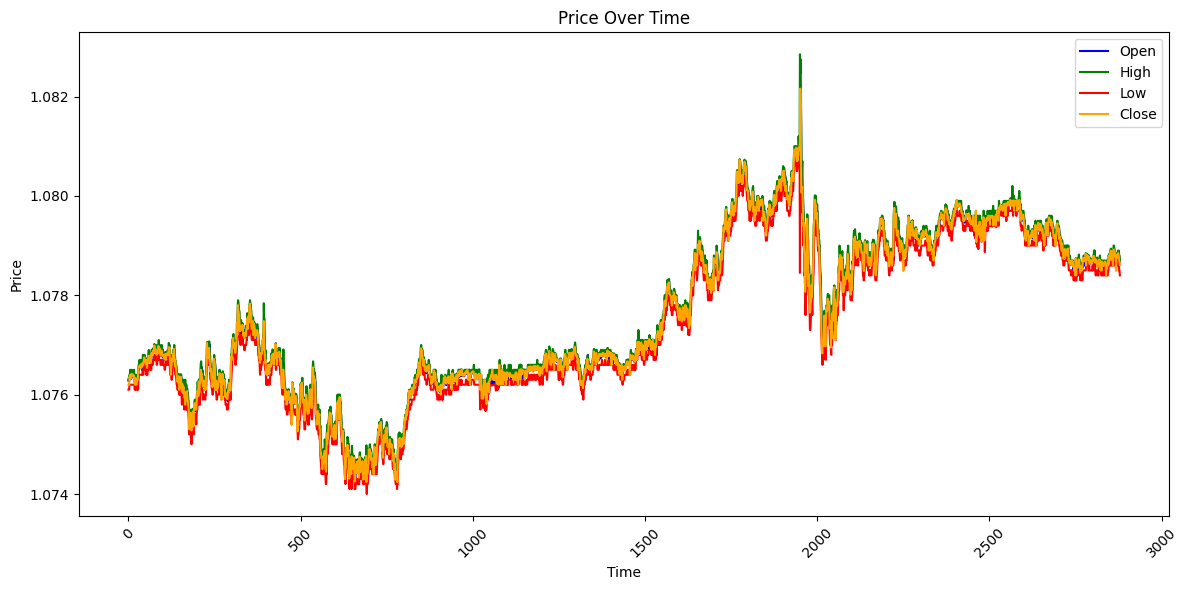

In [30]:
import matplotlib.pyplot as plt


# Plot the open, high, low, close prices over time
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['open'], label='Open', color='b')
plt.plot(df.index, df['high'], label='High', color='g')
plt.plot(df.index, df['low'], label='Low', color='r')
plt.plot(df.index, df['close'], label='Close', color='orange')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Price Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
!pip inst

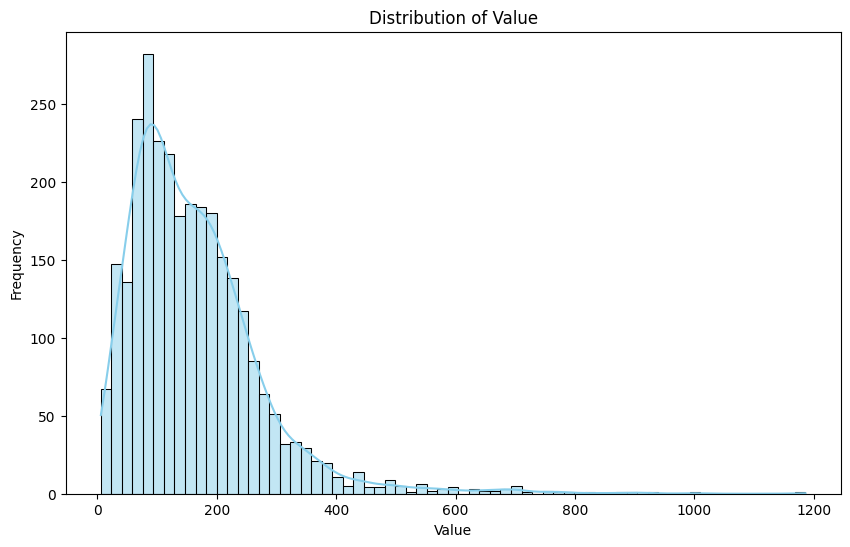

In [32]:
import seaborn as sns

# Plot value distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['value'], kde=True, color='skyblue')
plt.title('Distribution of Value')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


dist of values seems reasonable, peaking around 150 at a point.

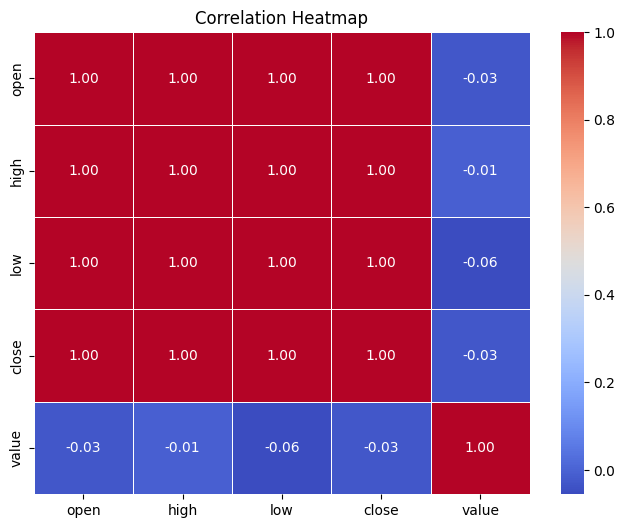

In [33]:
# Correlation heatmap between numerical features
correlation_matrix = df[['open', 'high', 'low', 'close', 'value']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


legit concerning correlation map, implies only usable columns could be value vs (open, close, low or high) 

### Sample visualizations of the raw data

In [5]:
### line charts of ohlc 

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date, time
import plotly.graph_objects as go

# Convert 'date' to string and 'time' to string (if not already)
df['date'] = df['date'].astype(str)
df['time'] = df['time'].astype(str)

# Combine and convert to datetime
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])

# Plot OHLC lines

# Plotly figure
fig = go.Figure()

fig.add_trace(go.Scatter(x=df['datetime'], y=df['open'], mode='lines', name='Open'))
fig.add_trace(go.Scatter(x=df['datetime'], y=df['high'], mode='lines', name='High'))
fig.add_trace(go.Scatter(x=df['datetime'], y=df['low'], mode='lines', name='Low'))
fig.add_trace(go.Scatter(x=df['datetime'], y=df['close'], mode='lines', name='Close'))

fig.update_layout(
    title='OHLC Prices Over Time',
    xaxis_title='Time',
    yaxis_title='Price',
    template='plotly_white',
    hovermode='x unified',
    legend_title='Price Type',
    xaxis=dict(rangeslider_visible=True)
)

fig.show()


In [7]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df['datetime'],
    open=df['open'],
    high=df['high'],
    low=df['low'],
    close=df['close']
)])

fig.update_layout(title='Candlestick Chart',
                  xaxis_title='Time',
                  yaxis_title='Price')
fig.show()


In [26]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=df['datetime'],
        y=df['value'],
        marker_color='skyblue',
        name='Trade Volume',
        hovertemplate='Time: %{x}<br>Volume: %{y}<extra></extra>',
    )
)

fig.update_layout(
    title='Trade Volume Over Time',
    xaxis_title='Time',
    yaxis_title='Volume',
    template='plotly_white',
    bargap=0.1,
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=15, label="15m", step="minute", stepmode="backward"),
                dict(count=1, label="1h", step="hour", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    height=450
)

fig.show()



In [12]:
# moving averages

df['SMA_3'] = df['close'].rolling(window=3).mean()


# Plotly figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['datetime'], y=df['close'],
    mode='lines+markers',
    name='Close Price',
    marker=dict(size=6)
))

fig.add_trace(go.Scatter(
    x=df['datetime'], y=df['SMA_3'],
    mode='lines',
    name='3-Period SMA',
    line=dict(dash='dash', color='orange')
))

fig.update_layout(
    title='Closing Price with 3-Period Simple Moving Average',
    xaxis_title='Time',
    yaxis_title='Price',
    hovermode='x unified',
    template='plotly_white',
    legend_title='Legend',
    xaxis=dict(rangeslider_visible=True)
)

fig.show()


In [13]:
# moving average after min max scaling


# Compute SMA
df['SMA_3'] = df['close'].rolling(window=3).mean()

# Min-Max Normalize Close and SMA_3
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

df['close_norm'] = minmax(df['close'])
df['SMA_3_norm'] = minmax(df['SMA_3'])

# Plotly figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['datetime'], y=df['close_norm'],
    mode='lines+markers',
    name='Normalized Close Price',
    marker=dict(size=6)
))

fig.add_trace(go.Scatter(
    x=df['datetime'], y=df['SMA_3_norm'],
    mode='lines',
    name='Normalized 3-Period SMA',
    line=dict(dash='dash', color='orange')
))

fig.update_layout(
    title='Normalized Close Price and 3-Period SMA',
    xaxis_title='Time',
    yaxis_title='Normalized Price',
    hovermode='x unified',
    template='plotly_white',
    legend_title='Legend',
    xaxis=dict(rangeslider_visible=True)
)

fig.show()